**LSA1 Signal Green Time Parser**

In [1]:
from pathlib import Path
import json
import pandas as pd

# ============================================================
# CODE 1: LSA1 SIGNAL GREEN TIME PARSER
# ============================================================

SIGNAL_DIR = Path(
    r"C:\Users\mogul\OneDrive\Masaüstü\mt_emre\signal_states\LD-LSA1_f3ab061d-0269-4e8e-b475-f89af4aed051"
)

OUT_DIR = Path(
    r"C:\Users\mogul\OneDrive\Masaüstü\mt_emre\saturation_rates\LSA1_saturation"
)
OUT_DIR.mkdir(parents=True, exist_ok=True)

OUT_CSV = OUT_DIR / "LSA1_green_time_summary.csv"
OUT_XLSX = OUT_DIR / "LSA1_green_time_summary.xlsx"

GREEN_STATE = 4

MOVEMENT_SIGNAL_MAP = {
    "West_Left":          {"signal_group": "K1", "signal_id": 1},
    "West_StraightRight": {"signal_group": "K2", "signal_id": 2},

    "South_StraightRight": {"signal_group": "K3", "signal_id": 3},

    "East_Right":         {"signal_group": "K6", "signal_id": 6},
    "East_StraightRight": {"signal_group": "K4", "signal_id": 4},
    "East_Left":          {"signal_group": "K5", "signal_id": 5},

    "North_Right":    {"signal_group": "K8", "signal_id": 8},
    "North_Straight": {"signal_group": "K7", "signal_id": 7},
}

# LSA1 signal data available days
SCENARIOS = {
    "weekday_morning": {
        "date": "2026-04-07",
        "start": "08:00:00",
        "end": "09:00:00",
    },
    "weekday_evening": {
        "date": "2026-04-07",
        "start": "16:00:00",
        "end": "17:00:00",
    },
    "weekend_morning": {
        "date": "2026-04-04",
        "start": "08:00:00",
        "end": "09:00:00",
    },
    "weekend_evening": {
        "date": "2026-04-04",
        "start": "16:00:00",
        "end": "17:00:00",
    },
}

rows = []

json_files = sorted(SIGNAL_DIR.glob("*.json"))
print(f"Found signal JSON files: {len(json_files)}")

for json_path in json_files:
    try:
        with open(json_path, "r", encoding="utf-8") as f:
            data = json.load(f)

        start_utc = pd.to_datetime(data["start"])

        for value in data.get("values", []):
            timestamp_utc = start_utc + pd.to_timedelta(value.get("offset", 0), unit="ms")
            timestamp_local = timestamp_utc.tz_convert("Europe/Berlin")

            sig_states = {
                item["id"]: item["sgState"]
                for item in value.get("sigState", [])
            }

            node_info = value.get("nodes", [{}])[0]

            for movement, info in MOVEMENT_SIGNAL_MAP.items():
                signal_id = info["signal_id"]

                if signal_id in sig_states:
                    sg_state = sig_states[signal_id]

                    rows.append({
                        "file": json_path.name,
                        "timestamp_local": timestamp_local,
                        "date": str(timestamp_local.date()),
                        "time": timestamp_local.time(),
                        "movement": movement,
                        "signal_group": info["signal_group"],
                        "signal_id": signal_id,
                        "sg_state": sg_state,
                        "is_green": sg_state == GREEN_STATE,
                        "program": node_info.get("program"),
                        "stage": node_info.get("stage"),
                        "cycCnt": node_info.get("cycCnt"),
                        "stgCnt": node_info.get("stgCnt"),
                        "stgTran": node_info.get("stgTran"),
                    })

    except Exception as e:
        print(f"Could not parse {json_path.name}: {e}")

df_signal = pd.DataFrame(rows)

print("Parsed signal rows:", len(df_signal))

if df_signal.empty:
    raise ValueError("No signal data parsed. Check SIGNAL_DIR.")

selected_parts = []

for scenario_name, scenario in SCENARIOS.items():
    start_t = pd.to_datetime(scenario["start"]).time()
    end_t = pd.to_datetime(scenario["end"]).time()

    temp = df_signal[
        (df_signal["date"] == scenario["date"]) &
        (df_signal["time"] >= start_t) &
        (df_signal["time"] < end_t)
    ].copy()

    temp["scenario"] = scenario_name
    temp["window_start"] = scenario["start"]
    temp["window_end"] = scenario["end"]

    selected_parts.append(temp)

df_selected_signal = pd.concat(selected_parts, ignore_index=True)

print("Selected signal rows:", len(df_selected_signal))

if df_selected_signal.empty:
    raise ValueError("No signal data found for selected representative scenarios.")

green_summary = (
    df_selected_signal
    .groupby([
        "scenario",
        "date",
        "window_start",
        "window_end",
        "movement",
        "signal_group",
        "signal_id"
    ])
    .agg(
        observed_seconds=("sg_state", "count"),
        green_seconds=("is_green", "sum"),
        cycle_count=("cycCnt", "nunique")
    )
    .reset_index()
)

green_summary["green_minutes"] = green_summary["green_seconds"] / 60
green_summary["green_share_percent"] = (
    green_summary["green_seconds"] / green_summary["observed_seconds"] * 100
)
green_summary["avg_cycle_time_s"] = (
    green_summary["observed_seconds"] / green_summary["cycle_count"]
)
green_summary["avg_green_per_cycle_s"] = (
    green_summary["green_seconds"] / green_summary["cycle_count"]
)

green_summary = green_summary.sort_values(["scenario", "movement"])

green_summary.to_csv(OUT_CSV, index=False, encoding="utf-8-sig")

df_selected_signal_excel = df_selected_signal.copy()
df_selected_signal_excel["timestamp_local"] = df_selected_signal_excel["timestamp_local"].astype(str)

with pd.ExcelWriter(OUT_XLSX, engine="openpyxl") as writer:
    green_summary.to_excel(writer, sheet_name="Green_Time_Summary", index=False)
    df_selected_signal_excel.to_excel(writer, sheet_name="Secondwise_Signal_Data", index=False)

print("Saved CSV:")
print(OUT_CSV)

print("\nSaved Excel:")
print(OUT_XLSX)

print("\nGreen time summary:")
print(green_summary)

Found signal JSON files: 320
Parsed signal rows: 4447232
Selected signal rows: 115216
Saved CSV:
C:\Users\mogul\OneDrive\Masaüstü\mt_emre\saturation_rates\LSA1_saturation\LSA1_green_time_summary.csv

Saved Excel:
C:\Users\mogul\OneDrive\Masaüstü\mt_emre\saturation_rates\LSA1_saturation\LSA1_green_time_summary.xlsx

Green time summary:
           scenario        date window_start window_end             movement  \
0   weekday_evening  2026-04-07     16:00:00   17:00:00            East_Left   
1   weekday_evening  2026-04-07     16:00:00   17:00:00           East_Right   
2   weekday_evening  2026-04-07     16:00:00   17:00:00   East_StraightRight   
3   weekday_evening  2026-04-07     16:00:00   17:00:00          North_Right   
4   weekday_evening  2026-04-07     16:00:00   17:00:00       North_Straight   
5   weekday_evening  2026-04-07     16:00:00   17:00:00  South_StraightRight   
6   weekday_evening  2026-04-07     16:00:00   17:00:00            West_Left   
7   weekday_evening  20

**LSA1 Green Share Figures**

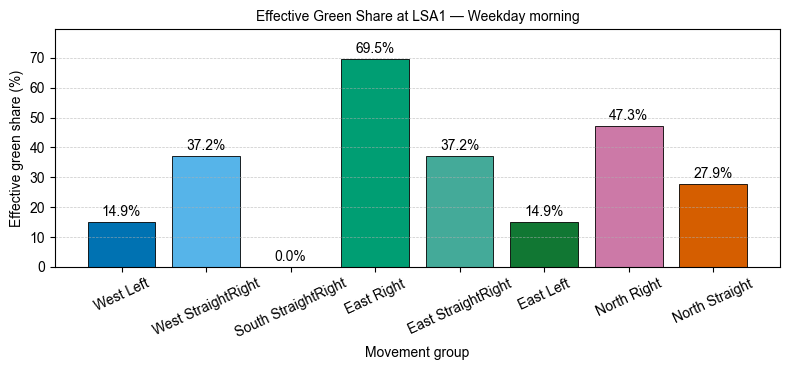

Saved:
C:\Users\mogul\OneDrive\Masaüstü\mt_emre\saturation_rates\LSA1_saturation\figures\LSA1_green_share_weekday_morning.png
C:\Users\mogul\OneDrive\Masaüstü\mt_emre\saturation_rates\LSA1_saturation\figures\LSA1_green_share_weekday_morning.svg


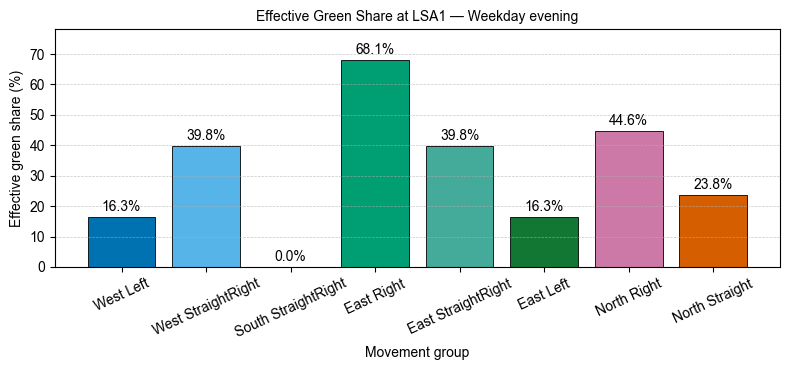

Saved:
C:\Users\mogul\OneDrive\Masaüstü\mt_emre\saturation_rates\LSA1_saturation\figures\LSA1_green_share_weekday_evening.png
C:\Users\mogul\OneDrive\Masaüstü\mt_emre\saturation_rates\LSA1_saturation\figures\LSA1_green_share_weekday_evening.svg


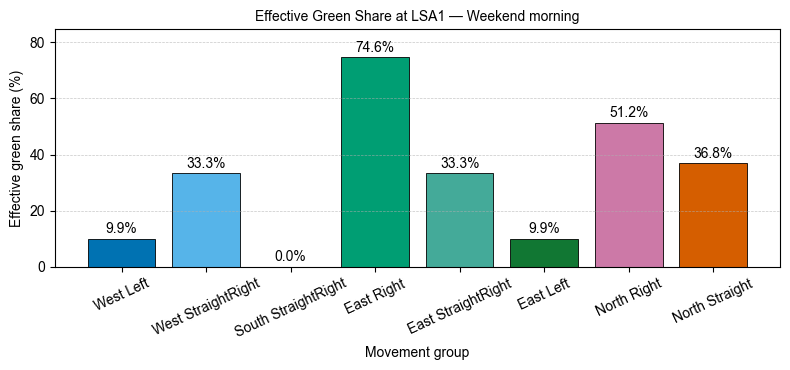

Saved:
C:\Users\mogul\OneDrive\Masaüstü\mt_emre\saturation_rates\LSA1_saturation\figures\LSA1_green_share_weekend_morning.png
C:\Users\mogul\OneDrive\Masaüstü\mt_emre\saturation_rates\LSA1_saturation\figures\LSA1_green_share_weekend_morning.svg


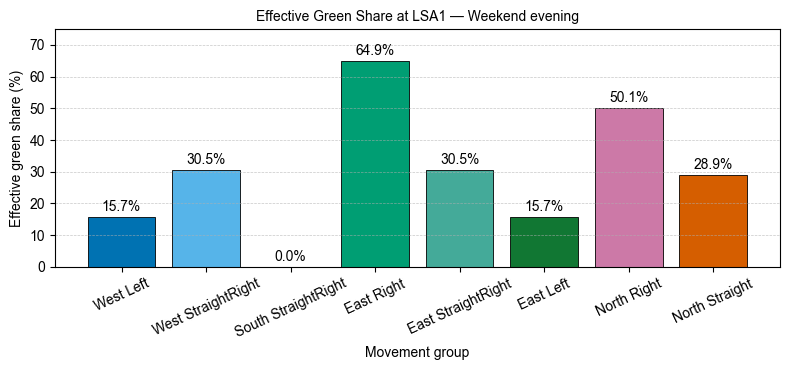

Saved:
C:\Users\mogul\OneDrive\Masaüstü\mt_emre\saturation_rates\LSA1_saturation\figures\LSA1_green_share_weekend_evening.png
C:\Users\mogul\OneDrive\Masaüstü\mt_emre\saturation_rates\LSA1_saturation\figures\LSA1_green_share_weekend_evening.svg


In [2]:
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt

# ============================================================
# CODE 1B: LSA1 GREEN SHARE FIGURES
# ============================================================

plt.rcParams.update({
    "font.family": "Arial",
    "font.size": 10,
    "axes.titlesize": 10,
    "axes.labelsize": 10,
    "xtick.labelsize": 10,
    "ytick.labelsize": 10,
    "legend.fontsize": 10,
})

BASE_DIR = Path(
    r"C:\Users\mogul\OneDrive\Masaüstü\mt_emre\saturation_rates\LSA1_saturation"
)

IN_CSV = BASE_DIR / "LSA1_green_time_summary.csv"

OUT_DIR = BASE_DIR / "figures"
OUT_DIR.mkdir(parents=True, exist_ok=True)

MOVEMENT_ORDER = [
    "West_Left",
    "West_StraightRight",
    "South_StraightRight",
    "East_Right",
    "East_StraightRight",
    "East_Left",
    "North_Right",
    "North_Straight",
]

SCENARIO_ORDER = [
    "weekday_morning",
    "weekday_evening",
    "weekend_morning",
    "weekend_evening",
]

SCENARIO_LABELS = {
    "weekday_morning": "Weekday morning",
    "weekday_evening": "Weekday evening",
    "weekend_morning": "Weekend morning",
    "weekend_evening": "Weekend evening",
}

MOVEMENT_COLORS = {
    "West_Left": "#0072B2",
    "West_StraightRight": "#56B4E9",
    "South_StraightRight": "#E69F00",
    "East_Right": "#009E73",
    "East_StraightRight": "#44AA99",
    "East_Left": "#117733",
    "North_Right": "#CC79A7",
    "North_Straight": "#D55E00",
}

def clean_label(x):
    return str(x).replace("_", " ")

df = pd.read_csv(IN_CSV)

df["movement"] = pd.Categorical(
    df["movement"],
    categories=MOVEMENT_ORDER,
    ordered=True
)

df["scenario"] = pd.Categorical(
    df["scenario"],
    categories=SCENARIO_ORDER,
    ordered=True
)

df = df.sort_values(["scenario", "movement"])

for scenario in SCENARIO_ORDER:
    temp = df[df["scenario"] == scenario].sort_values("movement")
    label = SCENARIO_LABELS[scenario]

    fig, ax = plt.subplots(figsize=(8.0, 3.8))

    bars = ax.bar(
        [clean_label(x) for x in temp["movement"].astype(str)],
        temp["green_share_percent"],
        color=[MOVEMENT_COLORS[x] for x in temp["movement"].astype(str)],
        edgecolor="black",
        linewidth=0.6
    )

    ax.set_title(f"Effective Green Share at LSA1 — {label}")
    ax.set_xlabel("Movement group")
    ax.set_ylabel("Effective green share (%)")
    ax.set_ylim(0, max(70, temp["green_share_percent"].max() + 10))
    ax.grid(axis="y", linestyle="--", linewidth=0.5, alpha=0.7)
    ax.tick_params(axis="x", rotation=25)

    for bar, value in zip(bars, temp["green_share_percent"]):
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            value + 1,
            f"{value:.1f}%",
            ha="center",
            va="bottom"
        )

    plt.tight_layout()

    out_png = OUT_DIR / f"LSA1_green_share_{scenario}.png"
    out_svg = OUT_DIR / f"LSA1_green_share_{scenario}.svg"

    plt.savefig(out_png, dpi=300, bbox_inches="tight")
    plt.savefig(out_svg, bbox_inches="tight")
    plt.show()

    print("Saved:")
    print(out_png)
    print(out_svg)

**LSA1 Phase Pattern Extractor**

In [3]:
from pathlib import Path
import json
import pandas as pd

# ============================================================
# CODE 5: LSA1 PHASE PATTERN EXTRACTOR
# ============================================================

SIGNAL_DIR = Path(
    r"C:\Users\mogul\OneDrive\Masaüstü\mt_emre\signal_states\LD-LSA1_f3ab061d-0269-4e8e-b475-f89af4aed051"
)

OUT_DIR = Path(
    r"C:\Users\mogul\OneDrive\Masaüstü\mt_emre\saturation_rates\LSA1_saturation"
)
OUT_DIR.mkdir(parents=True, exist_ok=True)

SCENARIO_NAME = "weekday_morning"
TARGET_DATE = "2026-04-07"
WINDOW_START = "08:00:00"
WINDOW_END = "09:00:00"

OUT_CSV = OUT_DIR / f"LSA1_phase_blocks_{SCENARIO_NAME}.csv"
OUT_XLSX = OUT_DIR / f"LSA1_phase_blocks_{SCENARIO_NAME}.xlsx"

SIGNAL_GROUPS = {
    "K1": 1,
    "K2": 2,
    "K3": 3,
    "K4": 4,
    "K5": 5,
    "K6": 6,
    "K7": 7,
    "K8": 8,
}

GROUP_COLUMNS = ["K1", "K2", "K3", "K4", "K5", "K6", "K7", "K8"]

rows = []

for json_path in sorted(SIGNAL_DIR.glob("*.json")):
    with open(json_path, "r", encoding="utf-8") as f:
        data = json.load(f)

    start_utc = pd.to_datetime(data["start"])

    for value in data.get("values", []):
        timestamp_utc = start_utc + pd.to_timedelta(value.get("offset", 0), unit="ms")
        timestamp_local = timestamp_utc.tz_convert("Europe/Berlin")

        if str(timestamp_local.date()) != TARGET_DATE:
            continue

        start_t = pd.to_datetime(WINDOW_START).time()
        end_t = pd.to_datetime(WINDOW_END).time()

        if not (start_t <= timestamp_local.time() < end_t):
            continue

        sig_states = {
            item["id"]: item["sgState"]
            for item in value.get("sigState", [])
        }

        node_info = value.get("nodes", [{}])[0]

        row = {
            "timestamp_local": timestamp_local,
            "date": str(timestamp_local.date()),
            "time": timestamp_local.time(),
            "program": node_info.get("program"),
            "stage": node_info.get("stage"),
            "cycCnt": node_info.get("cycCnt"),
            "stgCnt": node_info.get("stgCnt"),
            "stgTran": node_info.get("stgTran"),
        }

        for group_name, signal_id in SIGNAL_GROUPS.items():
            row[group_name] = sig_states.get(signal_id)

        rows.append(row)

df = pd.DataFrame(rows)

if df.empty:
    raise ValueError("No signal data found for selected date and time window.")

df = df.sort_values("timestamp_local").reset_index(drop=True)

for col in GROUP_COLUMNS:
    if df[col].isna().any():
        raise ValueError(f"{col} has missing values. Check signal mapping.")
    df[col] = df[col].astype(int)

df["pattern"] = df[GROUP_COLUMNS].astype(str).agg("-".join, axis=1)

df["block_id"] = (df["pattern"] != df["pattern"].shift()).cumsum()

phase_blocks = (
    df.groupby("block_id")
    .agg(
        start_time=("timestamp_local", "first"),
        end_time=("timestamp_local", "last"),
        date=("date", "first"),
        K1=("K1", "first"),
        K2=("K2", "first"),
        K3=("K3", "first"),
        K4=("K4", "first"),
        K5=("K5", "first"),
        K6=("K6", "first"),
        K7=("K7", "first"),
        K8=("K8", "first"),
        pattern=("pattern", "first"),
        stage=("stage", "first"),
        program=("program", "first"),
        n_seconds=("pattern", "count"),
    )
    .reset_index()
)

phase_blocks["duration_s"] = phase_blocks["n_seconds"]

pattern_summary = (
    phase_blocks
    .groupby(["pattern"] + GROUP_COLUMNS)
    .agg(
        occurrences=("block_id", "count"),
        total_duration_s=("duration_s", "sum"),
        mean_duration_s=("duration_s", "mean"),
        median_duration_s=("duration_s", "median"),
        min_duration_s=("duration_s", "min"),
        max_duration_s=("duration_s", "max"),
    )
    .reset_index()
    .sort_values("total_duration_s", ascending=False)
)

phase_blocks_excel = phase_blocks.copy()
phase_blocks_excel["start_time"] = phase_blocks_excel["start_time"].astype(str)
phase_blocks_excel["end_time"] = phase_blocks_excel["end_time"].astype(str)

df_excel = df.copy()
df_excel["timestamp_local"] = df_excel["timestamp_local"].astype(str)

phase_blocks_excel.to_csv(OUT_CSV, index=False, encoding="utf-8-sig")

with pd.ExcelWriter(OUT_XLSX, engine="openpyxl") as writer:
    phase_blocks_excel.to_excel(writer, sheet_name="Phase_Blocks", index=False)
    pattern_summary.to_excel(writer, sheet_name="Pattern_Summary", index=False)
    df_excel.to_excel(writer, sheet_name="Secondwise_K1_K8", index=False)

print("Saved CSV:")
print(OUT_CSV)

print("\nSaved Excel:")
print(OUT_XLSX)

print("\nTop recurring patterns:")
print(pattern_summary.head(20))

Saved CSV:
C:\Users\mogul\OneDrive\Masaüstü\mt_emre\saturation_rates\LSA1_saturation\LSA1_phase_blocks_weekday_morning.csv

Saved Excel:
C:\Users\mogul\OneDrive\Masaüstü\mt_emre\saturation_rates\LSA1_saturation\LSA1_phase_blocks_weekday_morning.xlsx

Top recurring patterns:
            pattern  K1  K2  K3  K4  K5  K6  K7  K8  occurrences  \
11  2-4-2-4-2-4-2-2   2   4   2   4   2   4   2   2           40   
8   2-2-2-2-2-4-4-4   2   2   2   2   2   4   4   4           41   
15  4-2-2-2-4-2-2-4   4   2   2   2   4   2   2   4           40   
14  4-2-2-2-4-2-2-2   4   2   2   2   4   2   2   2           40   
10  2-3-2-3-2-3-2-2   2   3   2   3   2   3   2   2           40   
13  3-2-2-2-3-2-2-4   3   2   2   2   3   2   2   4           40   
5   2-2-2-2-2-4-2-3   2   2   2   2   2   4   2   3           40   
1   2-2-2-2-2-2-2-4   2   2   2   2   2   2   2   4           40   
7   2-2-2-2-2-4-3-4   2   2   2   2   2   4   3   4           40   
2   2-2-2-2-2-2-4-4   2   2   2   2   2   2  

**Representative phase table generation**

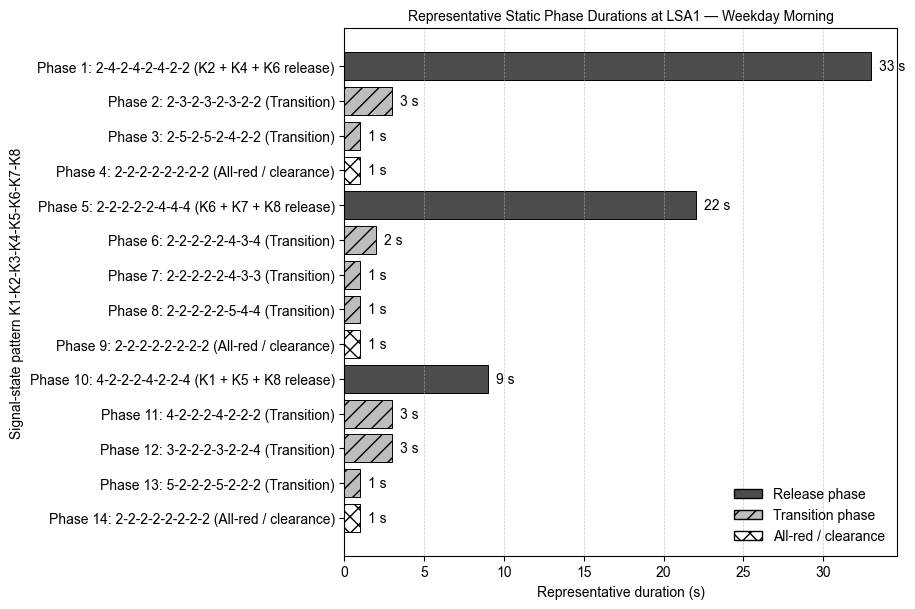

Saved:
C:\Users\mogul\OneDrive\Masaüstü\mt_emre\saturation_rates\LSA1_saturation\figures\LSA1_representative_phase_durations_weekday_morning_accessible.png
C:\Users\mogul\OneDrive\Masaüstü\mt_emre\saturation_rates\LSA1_saturation\figures\LSA1_representative_phase_durations_weekday_morning_accessible.svg

Representative static phase table:
    phase          pattern  phase_type           description  \
0       1  2-4-2-4-2-4-2-2     Release  K2 + K4 + K6 release   
1       2  2-3-2-3-2-3-2-2  Transition            Transition   
2       3  2-5-2-5-2-4-2-2  Transition            Transition   
3       4  2-2-2-2-2-2-2-2   Clearance   All-red / clearance   
4       5  2-2-2-2-2-4-4-4     Release  K6 + K7 + K8 release   
5       6  2-2-2-2-2-4-3-4  Transition            Transition   
6       7  2-2-2-2-2-4-3-3  Transition            Transition   
7       8  2-2-2-2-2-5-4-4  Transition            Transition   
8       9  2-2-2-2-2-2-2-2   Clearance   All-red / clearance   
9      10  4-2-2-2-

In [4]:
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt

# ============================================================
# CODE 5B: LSA1 REPRESENTATIVE PHASE DURATION FIGURE
# ============================================================

plt.rcParams.update({
    "font.family": "Arial",
    "font.size": 10,
    "axes.titlesize": 10,
    "axes.labelsize": 10,
    "xtick.labelsize": 10,
    "ytick.labelsize": 10,
    "legend.fontsize": 10,
})

BASE_DIR = Path(
    r"C:\Users\mogul\OneDrive\Masaüstü\mt_emre\saturation_rates\LSA1_saturation"
)

IN_XLSX = BASE_DIR / "LSA1_phase_blocks_weekday_morning.xlsx"

OUT_DIR = BASE_DIR / "figures"
OUT_DIR.mkdir(parents=True, exist_ok=True)

OUT_PNG = OUT_DIR / "LSA1_representative_phase_durations_weekday_morning_accessible.png"
OUT_SVG = OUT_DIR / "LSA1_representative_phase_durations_weekday_morning_accessible.svg"

pattern_summary = pd.read_excel(IN_XLSX, sheet_name="Pattern_Summary")

duration_lookup = {
    row["pattern"]: int(round(row["mean_duration_s"]))
    for _, row in pattern_summary.iterrows()
}

# Pattern order: K1-K2-K3-K4-K5-K6-K7-K8
representative_rows = [
    {
        "phase": 1,
        "pattern": "2-4-2-4-2-4-2-2",
        "phase_type": "Release",
        "description": "K2 + K4 + K6 release"
    },
    {
        "phase": 2,
        "pattern": "2-3-2-3-2-3-2-2",
        "phase_type": "Transition",
        "description": "Transition"
    },
    {
        "phase": 3,
        "pattern": "2-5-2-5-2-4-2-2",
        "phase_type": "Transition",
        "description": "Transition"
    },
    {
        "phase": 4,
        "pattern": "2-2-2-2-2-2-2-2",
        "phase_type": "Clearance",
        "description": "All-red / clearance"
    },
    {
        "phase": 5,
        "pattern": "2-2-2-2-2-4-4-4",
        "phase_type": "Release",
        "description": "K6 + K7 + K8 release"
    },
    {
        "phase": 6,
        "pattern": "2-2-2-2-2-4-3-4",
        "phase_type": "Transition",
        "description": "Transition"
    },
    {
        "phase": 7,
        "pattern": "2-2-2-2-2-4-3-3",
        "phase_type": "Transition",
        "description": "Transition"
    },
    {
        "phase": 8,
        "pattern": "2-2-2-2-2-5-4-4",
        "phase_type": "Transition",
        "description": "Transition"
    },
    {
        "phase": 9,
        "pattern": "2-2-2-2-2-2-2-2",
        "phase_type": "Clearance",
        "description": "All-red / clearance"
    },
    {
        "phase": 10,
        "pattern": "4-2-2-2-4-2-2-4",
        "phase_type": "Release",
        "description": "K1 + K5 + K8 release"
    },
    {
        "phase": 11,
        "pattern": "4-2-2-2-4-2-2-2",
        "phase_type": "Transition",
        "description": "Transition"
    },
    {
        "phase": 12,
        "pattern": "3-2-2-2-3-2-2-4",
        "phase_type": "Transition",
        "description": "Transition"
    },
    {
        "phase": 13,
        "pattern": "5-2-2-2-5-2-2-2",
        "phase_type": "Transition",
        "description": "Transition"
    },
    {
        "phase": 14,
        "pattern": "2-2-2-2-2-2-2-2",
        "phase_type": "Clearance",
        "description": "All-red / clearance"
    },
]

df = pd.DataFrame(representative_rows)
df["representative_duration_s"] = df["pattern"].map(duration_lookup)

missing = df[df["representative_duration_s"].isna()]
if not missing.empty:
    raise ValueError(
        "Some representative patterns were not found:\n"
        + str(missing[["phase", "pattern", "description"]])
    )

df["representative_duration_s"] = df["representative_duration_s"].astype(int)

STYLE = {
    "Release": {
        "color": "#4D4D4D",
        "hatch": "",
        "label": "Release phase"
    },
    "Transition": {
        "color": "#BDBDBD",
        "hatch": "//",
        "label": "Transition phase"
    },
    "Clearance": {
        "color": "#FFFFFF",
        "hatch": "xx",
        "label": "All-red / clearance"
    },
}

fig, ax = plt.subplots(figsize=(9.2, 6.2))

y_labels = [
    f"Phase {row.phase}: {row.pattern} ({row.description})"
    for _, row in df.iterrows()
]

for i, row in df.iterrows():
    style = STYLE[row["phase_type"]]

    ax.barh(
        y_labels[i],
        row["representative_duration_s"],
        color=style["color"],
        edgecolor="black",
        linewidth=0.7,
        hatch=style["hatch"]
    )

    ax.text(
        row["representative_duration_s"] + 0.5,
        i,
        f"{row['representative_duration_s']} s",
        va="center"
    )

ax.set_title("Representative Static Phase Durations at LSA1 — Weekday Morning")
ax.set_xlabel("Representative duration (s)")
ax.set_ylabel("Signal-state pattern K1-K2-K3-K4-K5-K6-K7-K8")
ax.grid(axis="x", linestyle="--", linewidth=0.5, alpha=0.7)
ax.invert_yaxis()

legend_handles = []
legend_labels = []

for _, style in STYLE.items():
    handle = plt.Rectangle(
        (0, 0),
        1,
        1,
        facecolor=style["color"],
        edgecolor="black",
        hatch=style["hatch"]
    )
    legend_handles.append(handle)
    legend_labels.append(style["label"])

ax.legend(
    legend_handles,
    legend_labels,
    frameon=False,
    loc="lower right"
)

plt.tight_layout()

plt.savefig(OUT_PNG, dpi=300, bbox_inches="tight")
plt.savefig(OUT_SVG, bbox_inches="tight")
plt.show()

print("Saved:")
print(OUT_PNG)
print(OUT_SVG)

print("\nRepresentative static phase table:")
print(df[[
    "phase",
    "pattern",
    "phase_type",
    "description",
    "representative_duration_s"
]])

print("\nApproximate representative cycle length:")
print(df["representative_duration_s"].sum(), "seconds")

**For LSA1, the signal-state analysis revealed three dominant release structures. The longest release phase corresponds to the combined release of K2, K4 and K6, with an average duration of approximately 33 s. A second major release phase serves K6, K7 and K8 and lasts approximately 22 s. A shorter release phase serves K1, K5 and K8 with an average duration of approximately 9 s. The remaining short signal-state combinations were interpreted as transition and clearance states and used to derive an approximate static signal program for SUMO.**

**LSA1 Static SUMO TLS Program Generator**

In [5]:
from pathlib import Path
import pandas as pd
from xml.dom import minidom
import xml.etree.ElementTree as ET

# ============================================================
# CODE 6: LSA1 STATIC SUMO TLS PROGRAM GENERATOR
# ============================================================
# Purpose:
# - Read representative LSA1 phase pattern durations
# - Convert K1-K2-K3-K4-K5-K6-K7-K8 patterns into SUMO TLS states
# - Use NetEdit TLS link index mapping
# - Create static SUMO additional file for LSA1
# ============================================================

BASE_DIR = Path(
    r"C:\Users\mogul\OneDrive\Masaüstü\mt_emre\saturation_rates\LSA1_saturation"
)

IN_XLSX = BASE_DIR / "LSA1_phase_blocks_weekday_morning.xlsx"

OUT_XML = BASE_DIR / "LSA1_static_tls_weekday_morning.add.xml"
OUT_PHASE_TABLE_CSV = BASE_DIR / "LSA1_static_tls_weekday_morning_phase_table.csv"

# Change this if the real TLS id in NetEdit is different
TLS_ID = "LSA1"

PROGRAM_ID = "derived_weekday_morning"

# ============================================================
# SUMO TLS LINK INDEX MAPPING
# ============================================================
# index 0  -> North right        -> K8
# index 1  -> North straight     -> K7
# index 2  -> North straight     -> K7
# index 3  -> East right         -> K6
# index 4  -> East straight      -> K4
# index 5  -> East straight      -> K4
# index 6  -> East left          -> K5
# index 7  -> South right        -> K3
# index 8  -> South straight     -> K3
# index 9  -> West straight/right -> K2
# index 10 -> West straight/right -> K2
# index 11 -> West left          -> K1
# ============================================================

LINK_INDEX_TO_GROUP = {
    0: "K8",
    1: "K7",
    2: "K7",
    3: "K6",
    4: "K4",
    5: "K4",
    6: "K5",
    7: "K3",
    8: "K3",
    9: "K2",
    10: "K2",
    11: "K1",
}

# ============================================================
# REPRESENTATIVE PHASE SEQUENCE
# ============================================================
# Pattern order: K1-K2-K3-K4-K5-K6-K7-K8
# ============================================================

REPRESENTATIVE_PHASES = [
    {"phase": 1,  "pattern": "2-4-2-4-2-4-2-2", "phase_type": "Release",    "description": "K2 + K4 + K6 release"},
    {"phase": 2,  "pattern": "2-3-2-3-2-3-2-2", "phase_type": "Transition", "description": "Transition"},
    {"phase": 3,  "pattern": "2-5-2-5-2-4-2-2", "phase_type": "Transition", "description": "Transition"},
    {"phase": 4,  "pattern": "2-2-2-2-2-2-2-2", "phase_type": "Clearance",  "description": "All-red / clearance"},

    {"phase": 5,  "pattern": "2-2-2-2-2-4-4-4", "phase_type": "Release",    "description": "K6 + K7 + K8 release"},
    {"phase": 6,  "pattern": "2-2-2-2-2-4-3-4", "phase_type": "Transition", "description": "Transition"},
    {"phase": 7,  "pattern": "2-2-2-2-2-4-3-3", "phase_type": "Transition", "description": "Transition"},
    {"phase": 8,  "pattern": "2-2-2-2-2-5-4-4", "phase_type": "Transition", "description": "Transition"},
    {"phase": 9,  "pattern": "2-2-2-2-2-2-2-2", "phase_type": "Clearance",  "description": "All-red / clearance"},

    {"phase": 10, "pattern": "4-2-2-2-4-2-2-4", "phase_type": "Release",    "description": "K1 + K5 + K8 release"},
    {"phase": 11, "pattern": "4-2-2-2-4-2-2-2", "phase_type": "Transition", "description": "Transition"},
    {"phase": 12, "pattern": "3-2-2-2-3-2-2-4", "phase_type": "Transition", "description": "Transition"},
    {"phase": 13, "pattern": "5-2-2-2-5-2-2-2", "phase_type": "Transition", "description": "Transition"},
    {"phase": 14, "pattern": "2-2-2-2-2-2-2-2", "phase_type": "Clearance",  "description": "All-red / clearance"},
]

# ============================================================
# HELPER FUNCTIONS
# ============================================================

def sgstate_to_sumo_char(sg_state):
    if sg_state == 4:
        return "G"
    elif sg_state in [3, 5]:
        return "y"
    elif sg_state == 2:
        return "r"
    else:
        return "r"


def pattern_to_sumo_state(pattern):
    k1, k2, k3, k4, k5, k6, k7, k8 = [int(x) for x in pattern.split("-")]

    group_state = {
        "K1": sgstate_to_sumo_char(k1),
        "K2": sgstate_to_sumo_char(k2),
        "K3": sgstate_to_sumo_char(k3),
        "K4": sgstate_to_sumo_char(k4),
        "K5": sgstate_to_sumo_char(k5),
        "K6": sgstate_to_sumo_char(k6),
        "K7": sgstate_to_sumo_char(k7),
        "K8": sgstate_to_sumo_char(k8),
    }

    return "".join(
        group_state[LINK_INDEX_TO_GROUP[idx]]
        for idx in sorted(LINK_INDEX_TO_GROUP.keys())
    )

# ============================================================
# LOAD PATTERN SUMMARY
# ============================================================

pattern_summary = pd.read_excel(IN_XLSX, sheet_name="Pattern_Summary")

duration_lookup = {
    row["pattern"]: int(round(row["mean_duration_s"]))
    for _, row in pattern_summary.iterrows()
}

# ============================================================
# BUILD PHASE TABLE
# ============================================================

phase_rows = []

for phase in REPRESENTATIVE_PHASES:
    pattern = phase["pattern"]

    if pattern not in duration_lookup:
        raise ValueError(f"Pattern {pattern} not found in Pattern_Summary.")

    duration = duration_lookup[pattern]
    sumo_state = pattern_to_sumo_state(pattern)

    k1, k2, k3, k4, k5, k6, k7, k8 = [int(x) for x in pattern.split("-")]

    phase_rows.append({
        "phase": phase["phase"],
        "pattern_K1_K2_K3_K4_K5_K6_K7_K8": pattern,
        "K1": k1,
        "K2": k2,
        "K3": k3,
        "K4": k4,
        "K5": k5,
        "K6": k6,
        "K7": k7,
        "K8": k8,
        "duration_s": duration,
        "sumo_state": sumo_state,
        "phase_type": phase["phase_type"],
        "description": phase["description"],
    })

phase_table = pd.DataFrame(phase_rows)

# ============================================================
# CREATE SUMO TLS XML
# ============================================================

additional = ET.Element("additional")

tl_logic = ET.SubElement(
    additional,
    "tlLogic",
    {
        "id": TLS_ID,
        "type": "static",
        "programID": PROGRAM_ID,
        "offset": "0",
    }
)

for _, row in phase_table.iterrows():
    ET.SubElement(
        tl_logic,
        "phase",
        {
            "duration": str(int(row["duration_s"])),
            "state": row["sumo_state"],
        }
    )

rough_string = ET.tostring(additional, encoding="utf-8")
parsed = minidom.parseString(rough_string)
pretty_xml = parsed.toprettyxml(indent="    ")

with open(OUT_XML, "w", encoding="utf-8") as f:
    f.write(pretty_xml)

phase_table.to_csv(OUT_PHASE_TABLE_CSV, index=False, encoding="utf-8-sig")

print("Saved SUMO TLS additional file:")
print(OUT_XML)

print("\nSaved phase table:")
print(OUT_PHASE_TABLE_CSV)

print("\nGenerated static phase table:")
print(phase_table)

print("\nSUMO state string length:")
print(len(phase_table.iloc[0]["sumo_state"]))

print("\nApproximate static cycle length:")
print(phase_table["duration_s"].sum(), "seconds")

Saved SUMO TLS additional file:
C:\Users\mogul\OneDrive\Masaüstü\mt_emre\saturation_rates\LSA1_saturation\LSA1_static_tls_weekday_morning.add.xml

Saved phase table:
C:\Users\mogul\OneDrive\Masaüstü\mt_emre\saturation_rates\LSA1_saturation\LSA1_static_tls_weekday_morning_phase_table.csv

Generated static phase table:
    phase pattern_K1_K2_K3_K4_K5_K6_K7_K8  K1  K2  K3  K4  K5  K6  K7  K8  \
0       1                 2-4-2-4-2-4-2-2   2   4   2   4   2   4   2   2   
1       2                 2-3-2-3-2-3-2-2   2   3   2   3   2   3   2   2   
2       3                 2-5-2-5-2-4-2-2   2   5   2   5   2   4   2   2   
3       4                 2-2-2-2-2-2-2-2   2   2   2   2   2   2   2   2   
4       5                 2-2-2-2-2-4-4-4   2   2   2   2   2   4   4   4   
5       6                 2-2-2-2-2-4-3-4   2   2   2   2   2   4   3   4   
6       7                 2-2-2-2-2-4-3-3   2   2   2   2   2   4   3   3   
7       8                 2-2-2-2-2-5-4-4   2   2   2   2   2   5

**FOR ALL SCENARIOS**

Found signal JSON files: 320
Parsed rows: 568851

Processing scenario: weekday_morning

Available patterns:
            pattern  occurrences  total_duration_s  mean_duration_s
11  2-4-2-4-2-4-2-2           40              1339        33.475000
8   2-2-2-2-2-4-4-4           41               885        21.585366
15  4-2-2-2-4-2-2-4           40               377         9.425000
14  4-2-2-2-4-2-2-2           40               120         3.000000
10  2-3-2-3-2-3-2-2           40               120         3.000000
13  3-2-2-2-3-2-2-4           40               120         3.000000
5   2-2-2-2-2-4-2-3           40                80         2.000000
1   2-2-2-2-2-2-2-4           40                80         2.000000
7   2-2-2-2-2-4-3-4           40                80         2.000000
2   2-2-2-2-2-2-4-4           40                80         2.000000
0   2-2-2-2-2-2-2-2           40                40         1.000000
6   2-2-2-2-2-4-3-3           40                40         1.000000
3   2-2-

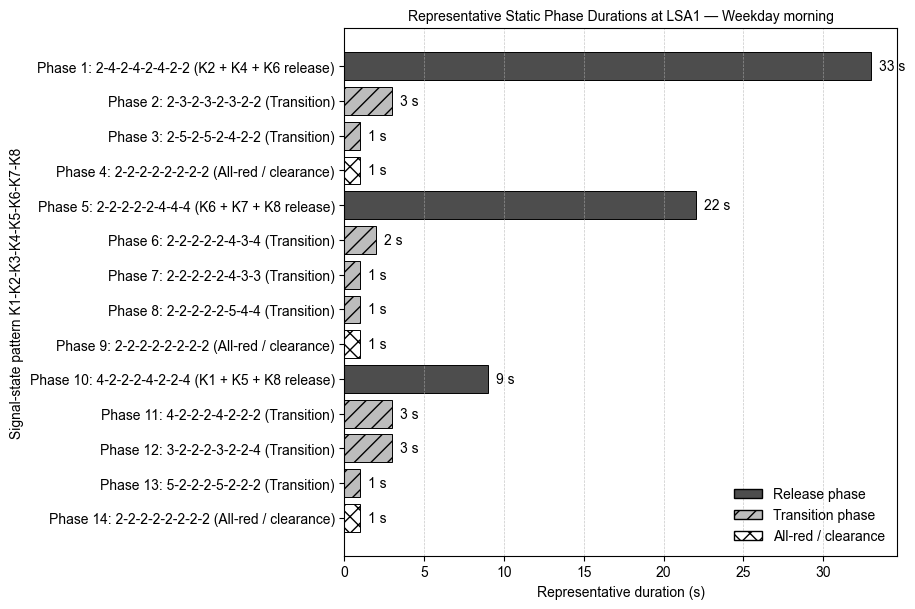

Saved figure:
C:\Users\mogul\OneDrive\Masaüstü\mt_emre\saturation_rates\LSA1_saturation\figures\LSA1_representative_phase_durations_weekday_morning.png
C:\Users\mogul\OneDrive\Masaüstü\mt_emre\saturation_rates\LSA1_saturation\figures\LSA1_representative_phase_durations_weekday_morning.svg

Saved SUMO TLS XML:
C:\Users\mogul\OneDrive\Masaüstü\mt_emre\saturation_rates\LSA1_saturation\static_tls_programs\LSA1_static_tls_weekday_morning.add.xml
Saved static phase table:
C:\Users\mogul\OneDrive\Masaüstü\mt_emre\saturation_rates\LSA1_saturation\static_tls_programs\LSA1_static_tls_weekday_morning_phase_table.csv
SUMO state string length: 12
Approximate static cycle length: 82 s

Processing scenario: weekday_evening

Available patterns:
            pattern  occurrences  total_duration_s  mean_duration_s
11  2-4-2-4-2-4-2-2           40              1432        35.800000
8   2-2-2-2-2-4-4-4           41               735        17.926829
15  4-2-2-2-4-2-2-4           40               427       

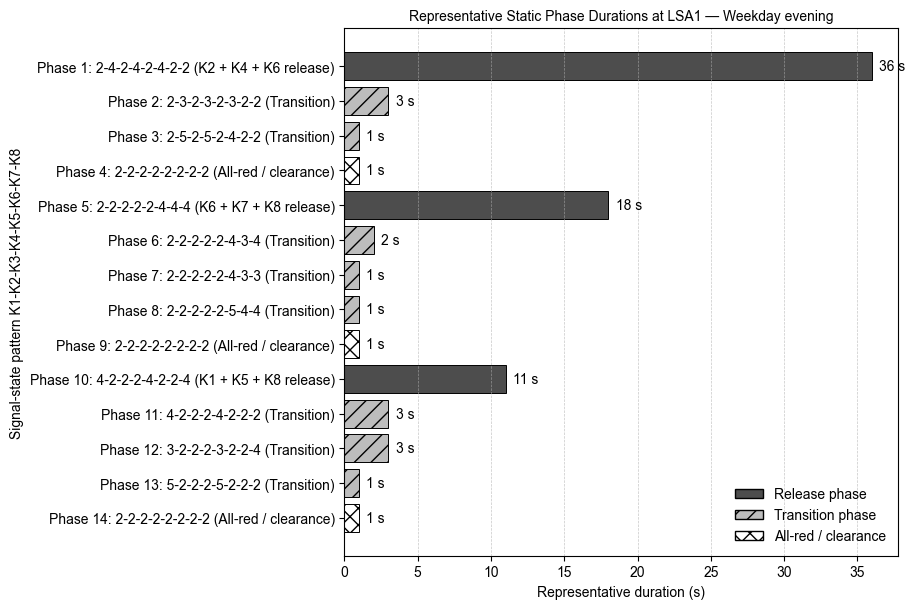

Saved figure:
C:\Users\mogul\OneDrive\Masaüstü\mt_emre\saturation_rates\LSA1_saturation\figures\LSA1_representative_phase_durations_weekday_evening.png
C:\Users\mogul\OneDrive\Masaüstü\mt_emre\saturation_rates\LSA1_saturation\figures\LSA1_representative_phase_durations_weekday_evening.svg

Saved SUMO TLS XML:
C:\Users\mogul\OneDrive\Masaüstü\mt_emre\saturation_rates\LSA1_saturation\static_tls_programs\LSA1_static_tls_weekday_evening.add.xml
Saved static phase table:
C:\Users\mogul\OneDrive\Masaüstü\mt_emre\saturation_rates\LSA1_saturation\static_tls_programs\LSA1_static_tls_weekday_evening_phase_table.csv
SUMO state string length: 12
Approximate static cycle length: 83 s

Processing scenario: weekend_morning

Available patterns:
            pattern  occurrences  total_duration_s  mean_duration_s
8   2-2-2-2-2-4-4-4           41              1206        29.414634
11  2-4-2-4-2-4-2-2           40              1199        29.975000
15  4-2-2-2-4-2-2-4           40               196       

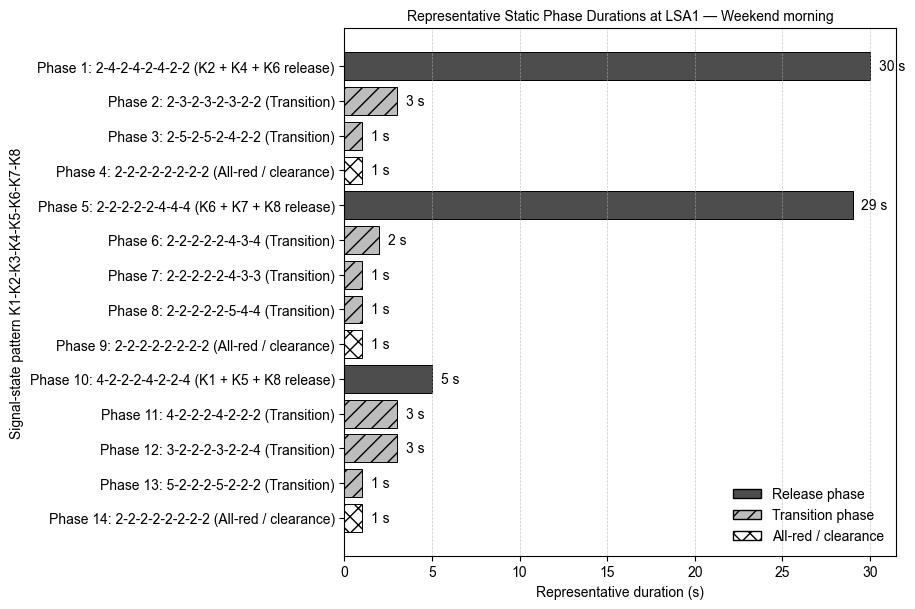

Saved figure:
C:\Users\mogul\OneDrive\Masaüstü\mt_emre\saturation_rates\LSA1_saturation\figures\LSA1_representative_phase_durations_weekend_morning.png
C:\Users\mogul\OneDrive\Masaüstü\mt_emre\saturation_rates\LSA1_saturation\figures\LSA1_representative_phase_durations_weekend_morning.svg

Saved SUMO TLS XML:
C:\Users\mogul\OneDrive\Masaüstü\mt_emre\saturation_rates\LSA1_saturation\static_tls_programs\LSA1_static_tls_weekend_morning.add.xml
Saved static phase table:
C:\Users\mogul\OneDrive\Masaüstü\mt_emre\saturation_rates\LSA1_saturation\static_tls_programs\LSA1_static_tls_weekend_morning_phase_table.csv
SUMO state string length: 12
Approximate static cycle length: 82 s

Processing scenario: weekend_evening

Available patterns:
            pattern  occurrences  total_duration_s  mean_duration_s
11  2-4-2-4-2-4-2-2           50              1097        21.940000
8   2-2-2-2-2-4-4-4           50               889        17.780000
15  4-2-2-2-4-2-2-4           50               364       

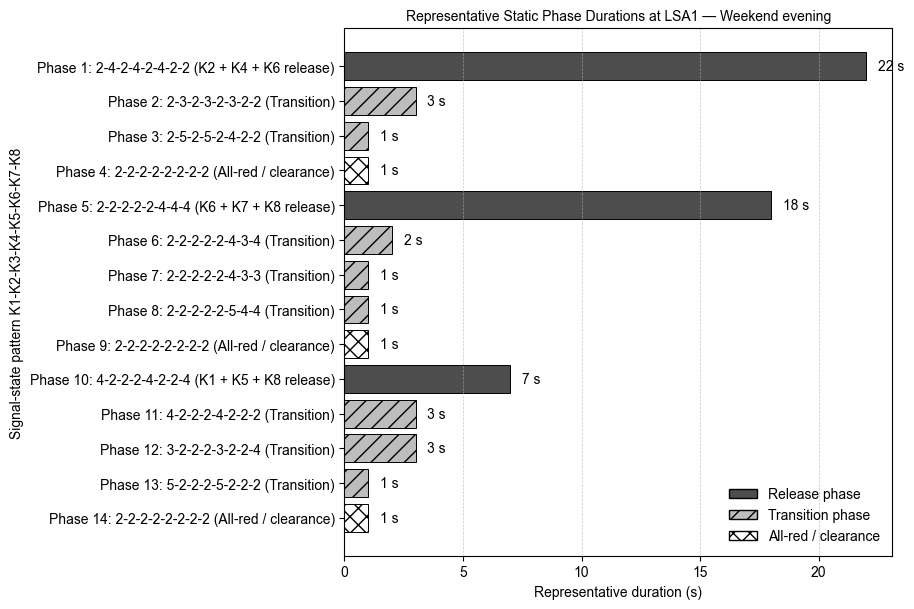

Saved figure:
C:\Users\mogul\OneDrive\Masaüstü\mt_emre\saturation_rates\LSA1_saturation\figures\LSA1_representative_phase_durations_weekend_evening.png
C:\Users\mogul\OneDrive\Masaüstü\mt_emre\saturation_rates\LSA1_saturation\figures\LSA1_representative_phase_durations_weekend_evening.svg

Saved SUMO TLS XML:
C:\Users\mogul\OneDrive\Masaüstü\mt_emre\saturation_rates\LSA1_saturation\static_tls_programs\LSA1_static_tls_weekend_evening.add.xml
Saved static phase table:
C:\Users\mogul\OneDrive\Masaüstü\mt_emre\saturation_rates\LSA1_saturation\static_tls_programs\LSA1_static_tls_weekend_evening_phase_table.csv
SUMO state string length: 12
Approximate static cycle length: 65 s

DONE
Saved combined Excel:
C:\Users\mogul\OneDrive\Masaüstü\mt_emre\saturation_rates\LSA1_saturation\LSA1_all_scenarios_phase_patterns_and_static_tls.xlsx

Saved TLS XML files in:
C:\Users\mogul\OneDrive\Masaüstü\mt_emre\saturation_rates\LSA1_saturation\static_tls_programs

Saved figures in:
C:\Users\mogul\OneDrive\Ma

In [6]:
from pathlib import Path
import json
import pandas as pd
import matplotlib.pyplot as plt
import xml.etree.ElementTree as ET
from xml.dom import minidom

# ============================================================
# CODE 7: LSA1 STATIC TLS PROGRAMS + PHASE GRAPHS FOR ALL SCENARIOS
# ============================================================

plt.rcParams.update({
    "font.family": "Arial",
    "font.size": 10,
    "axes.titlesize": 10,
    "axes.labelsize": 10,
    "xtick.labelsize": 10,
    "ytick.labelsize": 10,
    "legend.fontsize": 10,
})

SIGNAL_DIR = Path(
    r"C:\Users\mogul\OneDrive\Masaüstü\mt_emre\signal_states\LD-LSA1_f3ab061d-0269-4e8e-b475-f89af4aed051"
)

OUT_DIR = Path(
    r"C:\Users\mogul\OneDrive\Masaüstü\mt_emre\saturation_rates\LSA1_saturation"
)
OUT_DIR.mkdir(parents=True, exist_ok=True)

FIG_DIR = OUT_DIR / "figures"
FIG_DIR.mkdir(parents=True, exist_ok=True)

TLS_DIR = OUT_DIR / "static_tls_programs"
TLS_DIR.mkdir(parents=True, exist_ok=True)

# Change this if the real SUMO TLS id is different
TLS_ID = "LSA1"

SCENARIOS = {
    "weekday_morning": {
        "date": "2026-04-07",
        "start": "08:00:00",
        "end": "09:00:00",
        "label": "Weekday morning",
    },
    "weekday_evening": {
        "date": "2026-04-07",
        "start": "16:00:00",
        "end": "17:00:00",
        "label": "Weekday evening",
    },
    "weekend_morning": {
        "date": "2026-04-04",
        "start": "08:00:00",
        "end": "09:00:00",
        "label": "Weekend morning",
    },
    "weekend_evening": {
        "date": "2026-04-04",
        "start": "16:00:00",
        "end": "17:00:00",
        "label": "Weekend evening",
    },
}

SIGNAL_GROUPS = {
    "K1": 1,
    "K2": 2,
    "K3": 3,
    "K4": 4,
    "K5": 5,
    "K6": 6,
    "K7": 7,
    "K8": 8,
}

GROUP_COLUMNS = ["K1", "K2", "K3", "K4", "K5", "K6", "K7", "K8"]

LINK_INDEX_TO_GROUP = {
    0: "K8",
    1: "K7",
    2: "K7",
    3: "K6",
    4: "K4",
    5: "K4",
    6: "K5",
    7: "K3",
    8: "K3",
    9: "K2",
    10: "K2",
    11: "K1",
}

REPRESENTATIVE_PHASE_SEQUENCE = [
    {"phase": 1,  "pattern": "2-4-2-4-2-4-2-2", "phase_type": "Release",    "description": "K2 + K4 + K6 release"},
    {"phase": 2,  "pattern": "2-3-2-3-2-3-2-2", "phase_type": "Transition", "description": "Transition"},
    {"phase": 3,  "pattern": "2-5-2-5-2-4-2-2", "phase_type": "Transition", "description": "Transition"},
    {"phase": 4,  "pattern": "2-2-2-2-2-2-2-2", "phase_type": "Clearance",  "description": "All-red / clearance"},

    {"phase": 5,  "pattern": "2-2-2-2-2-4-4-4", "phase_type": "Release",    "description": "K6 + K7 + K8 release"},
    {"phase": 6,  "pattern": "2-2-2-2-2-4-3-4", "phase_type": "Transition", "description": "Transition"},
    {"phase": 7,  "pattern": "2-2-2-2-2-4-3-3", "phase_type": "Transition", "description": "Transition"},
    {"phase": 8,  "pattern": "2-2-2-2-2-5-4-4", "phase_type": "Transition", "description": "Transition"},
    {"phase": 9,  "pattern": "2-2-2-2-2-2-2-2", "phase_type": "Clearance",  "description": "All-red / clearance"},

    {"phase": 10, "pattern": "4-2-2-2-4-2-2-4", "phase_type": "Release",    "description": "K1 + K5 + K8 release"},
    {"phase": 11, "pattern": "4-2-2-2-4-2-2-2", "phase_type": "Transition", "description": "Transition"},
    {"phase": 12, "pattern": "3-2-2-2-3-2-2-4", "phase_type": "Transition", "description": "Transition"},
    {"phase": 13, "pattern": "5-2-2-2-5-2-2-2", "phase_type": "Transition", "description": "Transition"},
    {"phase": 14, "pattern": "2-2-2-2-2-2-2-2", "phase_type": "Clearance",  "description": "All-red / clearance"},
]

STYLE = {
    "Release": {"color": "#4D4D4D", "hatch": "", "label": "Release phase"},
    "Transition": {"color": "#BDBDBD", "hatch": "//", "label": "Transition phase"},
    "Clearance": {"color": "#FFFFFF", "hatch": "xx", "label": "All-red / clearance"},
}

def sgstate_to_sumo_char(sg_state):
    if sg_state == 4:
        return "G"
    elif sg_state in [3, 5]:
        return "y"
    elif sg_state == 2:
        return "r"
    else:
        return "r"


def pattern_to_sumo_state(pattern):
    k1, k2, k3, k4, k5, k6, k7, k8 = [int(x) for x in pattern.split("-")]

    group_state = {
        "K1": sgstate_to_sumo_char(k1),
        "K2": sgstate_to_sumo_char(k2),
        "K3": sgstate_to_sumo_char(k3),
        "K4": sgstate_to_sumo_char(k4),
        "K5": sgstate_to_sumo_char(k5),
        "K6": sgstate_to_sumo_char(k6),
        "K7": sgstate_to_sumo_char(k7),
        "K8": sgstate_to_sumo_char(k8),
    }

    return "".join(
        group_state[LINK_INDEX_TO_GROUP[idx]]
        for idx in sorted(LINK_INDEX_TO_GROUP.keys())
    )


def save_sumo_tls_xml(phase_table, out_xml, program_id):
    additional = ET.Element("additional")

    tl_logic = ET.SubElement(
        additional,
        "tlLogic",
        {
            "id": TLS_ID,
            "type": "static",
            "programID": program_id,
            "offset": "0",
        }
    )

    for _, row in phase_table.iterrows():
        ET.SubElement(
            tl_logic,
            "phase",
            {
                "duration": str(int(row["duration_s"])),
                "state": row["sumo_state"],
            }
        )

    rough_string = ET.tostring(additional, encoding="utf-8")
    parsed = minidom.parseString(rough_string)
    pretty_xml = parsed.toprettyxml(indent="    ")

    with open(out_xml, "w", encoding="utf-8") as f:
        f.write(pretty_xml)


def plot_phase_durations(phase_table, scenario_name, scenario_label):
    out_png = FIG_DIR / f"LSA1_representative_phase_durations_{scenario_name}.png"
    out_svg = FIG_DIR / f"LSA1_representative_phase_durations_{scenario_name}.svg"

    fig, ax = plt.subplots(figsize=(9.2, 6.2))

    y_labels = [
        f"Phase {row.phase}: {row.pattern_K1_K2_K3_K4_K5_K6_K7_K8} ({row.description})"
        for _, row in phase_table.iterrows()
    ]

    for i, row in phase_table.iterrows():
        style = STYLE[row["phase_type"]]

        ax.barh(
            y_labels[i],
            row["duration_s"],
            color=style["color"],
            edgecolor="black",
            linewidth=0.7,
            hatch=style["hatch"]
        )

        ax.text(
            row["duration_s"] + 0.5,
            i,
            f"{int(row['duration_s'])} s",
            va="center"
        )

    ax.set_title(f"Representative Static Phase Durations at LSA1 — {scenario_label}")
    ax.set_xlabel("Representative duration (s)")
    ax.set_ylabel("Signal-state pattern K1-K2-K3-K4-K5-K6-K7-K8")
    ax.grid(axis="x", linestyle="--", linewidth=0.5, alpha=0.7)
    ax.invert_yaxis()

    legend_handles = []
    legend_labels = []

    for _, style in STYLE.items():
        handle = plt.Rectangle(
            (0, 0),
            1,
            1,
            facecolor=style["color"],
            edgecolor="black",
            hatch=style["hatch"]
        )
        legend_handles.append(handle)
        legend_labels.append(style["label"])

    ax.legend(legend_handles, legend_labels, frameon=False, loc="lower right")

    plt.tight_layout()
    plt.savefig(out_png, dpi=300, bbox_inches="tight")
    plt.savefig(out_svg, bbox_inches="tight")
    plt.show()

    print("Saved figure:")
    print(out_png)
    print(out_svg)


# ============================================================
# PARSE ALL SIGNAL FILES
# ============================================================

rows = []

json_files = sorted(SIGNAL_DIR.glob("*.json"))
print(f"Found signal JSON files: {len(json_files)}")

for json_path in json_files:
    try:
        with open(json_path, "r", encoding="utf-8") as f:
            data = json.load(f)

        start_utc = pd.to_datetime(data["start"])

        for value in data.get("values", []):
            timestamp_utc = start_utc + pd.to_timedelta(value.get("offset", 0), unit="ms")
            timestamp_local = timestamp_utc.tz_convert("Europe/Berlin")

            sig_states = {
                item["id"]: item["sgState"]
                for item in value.get("sigState", [])
            }

            node_info = value.get("nodes", [{}])[0]

            row = {
                "timestamp_local": timestamp_local,
                "date": str(timestamp_local.date()),
                "time": timestamp_local.time(),
                "program": node_info.get("program"),
                "stage": node_info.get("stage"),
                "cycCnt": node_info.get("cycCnt"),
                "stgCnt": node_info.get("stgCnt"),
                "stgTran": node_info.get("stgTran"),
            }

            for group_name, signal_id in SIGNAL_GROUPS.items():
                row[group_name] = sig_states.get(signal_id)

            rows.append(row)

    except Exception as e:
        print(f"Could not parse {json_path.name}: {e}")

df_all = pd.DataFrame(rows)

if df_all.empty:
    raise ValueError("No signal data parsed.")

print("Parsed rows:", len(df_all))

all_phase_blocks = []
all_pattern_summaries = []
all_static_phase_tables = []

for scenario_name, scenario in SCENARIOS.items():

    print("\n" + "=" * 70)
    print(f"Processing scenario: {scenario_name}")
    print("=" * 70)

    start_t = pd.to_datetime(scenario["start"]).time()
    end_t = pd.to_datetime(scenario["end"]).time()

    df = df_all[
        (df_all["date"] == scenario["date"]) &
        (df_all["time"] >= start_t) &
        (df_all["time"] < end_t)
    ].copy()

    if df.empty:
        print(f"No data found for {scenario_name}. Skipping.")
        continue

    df = df.sort_values("timestamp_local").reset_index(drop=True)

    for col in GROUP_COLUMNS:
        if df[col].isna().any():
            raise ValueError(f"{col} has missing values. Check signal_id mapping.")
        df[col] = df[col].astype(int)

    df["pattern"] = df[GROUP_COLUMNS].astype(str).agg("-".join, axis=1)
    df["block_id"] = (df["pattern"] != df["pattern"].shift()).cumsum()

    phase_blocks = (
        df.groupby("block_id")
        .agg(
            start_time=("timestamp_local", "first"),
            end_time=("timestamp_local", "last"),
            date=("date", "first"),
            K1=("K1", "first"),
            K2=("K2", "first"),
            K3=("K3", "first"),
            K4=("K4", "first"),
            K5=("K5", "first"),
            K6=("K6", "first"),
            K7=("K7", "first"),
            K8=("K8", "first"),
            pattern=("pattern", "first"),
            stage=("stage", "first"),
            program=("program", "first"),
            n_seconds=("pattern", "count"),
        )
        .reset_index()
    )

    phase_blocks["duration_s"] = phase_blocks["n_seconds"]
    phase_blocks["scenario"] = scenario_name
    phase_blocks["window_start"] = scenario["start"]
    phase_blocks["window_end"] = scenario["end"]

    pattern_summary = (
        phase_blocks
        .groupby(["scenario", "pattern"] + GROUP_COLUMNS)
        .agg(
            occurrences=("block_id", "count"),
            total_duration_s=("duration_s", "sum"),
            mean_duration_s=("duration_s", "mean"),
            median_duration_s=("duration_s", "median"),
            min_duration_s=("duration_s", "min"),
            max_duration_s=("duration_s", "max"),
        )
        .reset_index()
        .sort_values("total_duration_s", ascending=False)
    )

    duration_lookup = {
        str(row["pattern"]): int(round(row["mean_duration_s"]))
        for _, row in pattern_summary.iterrows()
    }

    print("\nAvailable patterns:")
    print(pattern_summary[["pattern", "occurrences", "total_duration_s", "mean_duration_s"]].head(20))

    static_rows = []

    for phase in REPRESENTATIVE_PHASE_SEQUENCE:
        pattern = phase["pattern"]

        if pattern not in duration_lookup:
            raise ValueError(
                f"Pattern {pattern} not found for {scenario_name}. "
                f"Available patterns are: {list(duration_lookup.keys())}"
            )

        duration = duration_lookup[pattern]
        sumo_state = pattern_to_sumo_state(pattern)
        k1, k2, k3, k4, k5, k6, k7, k8 = [int(x) for x in pattern.split("-")]

        static_rows.append({
            "scenario": scenario_name,
            "phase": phase["phase"],
            "pattern_K1_K2_K3_K4_K5_K6_K7_K8": pattern,
            "K1": k1,
            "K2": k2,
            "K3": k3,
            "K4": k4,
            "K5": k5,
            "K6": k6,
            "K7": k7,
            "K8": k8,
            "duration_s": duration,
            "sumo_state": sumo_state,
            "phase_type": phase["phase_type"],
            "description": phase["description"],
        })

    static_phase_table = pd.DataFrame(static_rows)

    program_id = f"derived_{scenario_name}"

    out_xml = TLS_DIR / f"LSA1_static_tls_{scenario_name}.add.xml"
    out_csv = TLS_DIR / f"LSA1_static_tls_{scenario_name}_phase_table.csv"

    save_sumo_tls_xml(static_phase_table, out_xml, program_id)
    static_phase_table.to_csv(out_csv, index=False, encoding="utf-8-sig")

    plot_phase_durations(static_phase_table, scenario_name, scenario["label"])

    print("\nSaved SUMO TLS XML:")
    print(out_xml)

    print("Saved static phase table:")
    print(out_csv)

    print("SUMO state string length:", len(static_phase_table.iloc[0]["sumo_state"]))
    print("Approximate static cycle length:", static_phase_table["duration_s"].sum(), "s")

    phase_blocks_excel = phase_blocks.copy()
    phase_blocks_excel["start_time"] = phase_blocks_excel["start_time"].astype(str)
    phase_blocks_excel["end_time"] = phase_blocks_excel["end_time"].astype(str)

    all_phase_blocks.append(phase_blocks_excel)
    all_pattern_summaries.append(pattern_summary)
    all_static_phase_tables.append(static_phase_table)

combined_phase_blocks = pd.concat(all_phase_blocks, ignore_index=True)
combined_pattern_summary = pd.concat(all_pattern_summaries, ignore_index=True)
combined_static_phase_table = pd.concat(all_static_phase_tables, ignore_index=True)

OUT_XLSX = OUT_DIR / "LSA1_all_scenarios_phase_patterns_and_static_tls.xlsx"

with pd.ExcelWriter(OUT_XLSX, engine="openpyxl") as writer:
    combined_phase_blocks.to_excel(writer, sheet_name="Phase_Blocks", index=False)
    combined_pattern_summary.to_excel(writer, sheet_name="Pattern_Summary", index=False)
    combined_static_phase_table.to_excel(writer, sheet_name="Static_TLS_Phase_Table", index=False)

print("\n" + "=" * 70)
print("DONE")
print("=" * 70)

print("Saved combined Excel:")
print(OUT_XLSX)

print("\nSaved TLS XML files in:")
print(TLS_DIR)

print("\nSaved figures in:")
print(FIG_DIR)

print("\nCycle lengths by scenario:")
print(
    combined_static_phase_table
    .groupby("scenario")["duration_s"]
    .sum()
    .reset_index(name="approx_static_cycle_length_s")
)

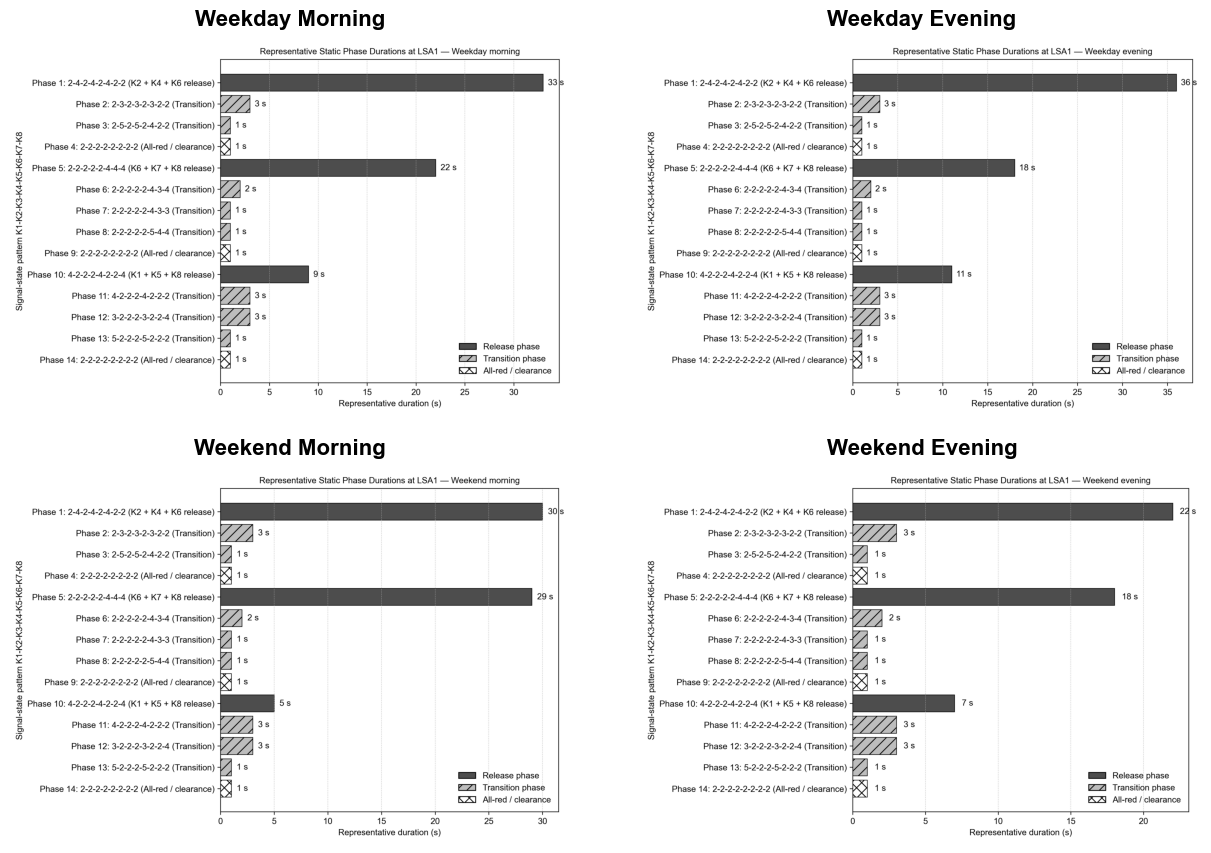

Saved: C:\Users\mogul\OneDrive\Masaüstü\mt_emre\saturation_rates\LSA1_saturation\figures\LSA1_representative_phase_durations_combined.png


In [1]:
from pathlib import Path
import matplotlib.pyplot as plt
import matplotlib.image as mpimg

# ============================================================
# THESIS STYLE
# ============================================================

plt.rcParams.update({
    "font.family": "Arial",
    "font.size": 13,
    "axes.titlesize": 15,
    "axes.labelsize": 13,
    "xtick.labelsize": 12,
    "ytick.labelsize": 12,
})

# ============================================================
# SETTINGS
# ============================================================

BASE_DIR = Path(
    r"C:\Users\mogul\OneDrive\Masaüstü\mt_emre\saturation_rates\LSA1_saturation\figures"
)

scenarios = [
    ("weekday_morning", "Weekday Morning"),
    ("weekday_evening", "Weekday Evening"),
    ("weekend_morning", "Weekend Morning"),
    ("weekend_evening", "Weekend Evening"),
]

prefix = "LSA1_representative_phase_durations"

out_file = BASE_DIR / "LSA1_representative_phase_durations_combined.png"

# ============================================================
# CREATE COMBINED FIGURE
# ============================================================

fig, axes = plt.subplots(2, 2, figsize=(13, 9))
axes = axes.flatten()

for ax, (scenario, title) in zip(axes, scenarios):

    img_path = BASE_DIR / f"{prefix}_{scenario}.png"

    if not img_path.exists():
        raise FileNotFoundError(f"File not found: {img_path}")

    img = mpimg.imread(img_path)

    ax.imshow(img)
    ax.set_title(title, fontsize=16, fontweight="bold", pad=12)
    ax.axis("off")

plt.tight_layout(pad=2.0)

plt.savefig(out_file, dpi=300, bbox_inches="tight")
plt.show()

print(f"Saved: {out_file}")